In [ ]:
# --- Setup: make the `ecp` support package available -----------------
# Colab opens a single notebook and installs nothing, so fetch `ecp` from
# the public repo if it isn't importable yet. On Binder/local it is already
# installed, so this cell is a fast no-op there.
try:
    import ecp  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/ramador09/elementary-computational-physics-public@main"],
        check=True,
    )


# 6.3 Metadynamics: Nitric Acid on Graphene

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume VI — Reactions and Free Energy",
    number="6.3",
    title="Metadynamics: Nitric Acid on Graphene",
    blurb="Filling the valleys to map the mountains: metadynamics deposits a running "
    "bias along chosen collective variables to push a system out of its basins, and the "
    "accumulated bias reconstructs the free-energy surface of nitric acid interacting "
    "with a graphene sheet.",
    difficulty="advanced",
    estimate="90–120 min",
    source="FS 2023 · Lecture 13 (metadynamics and collective variables)",
)

<ECP header: 2861 chars of HTML>

## Notebook overview

Ordinary molecular dynamics is trapped by barriers: a rare event like a bond breaking
may never happen on a simulable timescale. **Metadynamics** breaks the trap. It picks
a few **collective variables** (CVs), coordinates that describe the slow motion of
interest, and periodically deposits a small repulsive Gaussian **hill** at the
system's current position in CV space. The growing bias fills up whatever basin the
system sits in, eventually floating it over the barrier, and the sum of all the hills,
inverted, *is* the **free-energy surface**.

This is the course's exercise on metadynamics, applied to two nitric-acid molecules
over a graphene sheet, with the fast and cheap **density-functional tight-binding**
(DFTB) method for the forces. We take the course's committed output: the trajectory of
the collective variables (the `COLVAR` log) and the list of deposited hills (the
`HILLS` log). We render the system, follow the collective variables as the bias drives
the exploration, and reconstruct the free-energy surface by summing the hills.

> **Provenance.** This notebook develops **Lecture 13** of the course (metadynamics,
> collective variables, and free-energy surfaces), an exercise **designed by the
> author (Raymond Amador)**. The structure
> (`grly5x3_2hno3.xyz`) and the metadynamics logs (`COLVAR`, `HILLS`) are the course's
> own committed CP2K/DFTB results from a short "simple metadynamics" run. The full
> course credit is in the footer.

> **Reading a validation.** Each task closes with a check against an independent
> fact: the composition of the system, that the bias actually drove exploration, that
> the reconstructed surface is consistent with where the trajectory went. A ✗ flags a
> mismatch; a ✓ is strong evidence, not proof.

> **Scope.** This is a deliberately short teaching run, so the free-energy surface is
> qualitative, the bias filling the explored basin rather than fully converging a
> barrier. Energies are the committed values (Hartree, to kcal/mol). For the method
> see Laio & Parrinello {cite}`laio2002`.

## Theory in brief

### Collective variables

A collective variable $s(\mathbf R)$ is a function of the atomic coordinates chosen to
capture the slow degree of freedom, here **coordination numbers**: a smooth count of
how many atoms of one type lie within a cutoff of another (C–O between graphene and the
acid, N–O within the acid, H–C for a hydrogen approaching the sheet). Coordination
numbers vary continuously as bonds form and break, which makes them good reaction
coordinates.

### The metadynamics bias and the free-energy surface

Every $\tau$ steps a Gaussian of height $W$ and width $\sigma$ is added to the bias at
the current CV value $\mathbf s_t$:

```{math}
:label: eq-metad
V(\mathbf s, t) = \sum_{t' \le t} W \exp\!\left(-\sum_i \frac{(s_i - s_i(t'))^2}{2\sigma_i^2}\right).
```

The bias accumulates in the basins the system visits, raising their floor until the
system spills into the next basin. In the long-time limit the bias becomes the inverse
of the underlying free energy, so the **free-energy surface** is reconstructed
by summing the deposited hills and flipping the sign,
$F(\mathbf s) \approx -V(\mathbf s)$.

---
## Setup

The Setup below holds this notebook's data and instruments — nothing you are asked
to build. It is collapsed so the building stays yours; expand it whenever you want
the details.

<!-- setup-policy: v2 -->

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"
HARTREE_KCAL = 627.503
CPK = {"H": "#d9d9d9", "C": "#303030", "O": "#c0392b", "N": "#2c5fb0"}
CV_NAMES = ["C–O coordination", "N–O coordination", "H–C coordination"]


def data_file(name):
    """Locate a shipped data file, from the repo root (CI) or the notebook dir (Colab).

    Parameters
    ----------
    name : str
        File name (or relative path) under a ``data`` directory.

    Returns
    -------
    str
        The first existing path found.

    Raises
    ------
    FileNotFoundError
        If the file is not found under any candidate base.
    """
    for base in ("data", os.path.join("notebooks", "06-reactions-free-energy", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)


def read_xyz(name):
    """Read an .xyz file.

    Parameters
    ----------
    name : str
        File name (coordinates in Å).

    Returns
    -------
    tuple
        ``(elements, coords)``: a list of element symbols and an (N, 3)
        coordinate array in Å.
    """
    lines = open(data_file(name)).read().splitlines()
    n = int(lines[0].split()[0])
    els = [ln.split()[0] for ln in lines[2 : 2 + n]]
    xyz = np.array([[float(v) for v in ln.split()[1:4]] for ln in lines[2 : 2 + n]])
    return els, xyz

In [3]:
# A small orthographic ball-and-stick renderer, far clearer than a perspective
# scatter for a flat lattice: atoms are shaded discs (painter-sorted by depth so
# nearer atoms sit on top) and bonds are the short interatomic separations.
from matplotlib.patches import Circle  # noqa: E402
from matplotlib.lines import Line2D  # noqa: E402

DISPLAY_R = {"H": 0.34, "C": 0.44, "N": 0.44, "O": 0.44}  # drawing radii (Å)


def _lighten(color, f):
    """Blend an RGB colour a fraction ``f`` of the way toward white."""
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * f, g + (1 - g) * f, b + (1 - b) * f)


def draw_view(ax, els, xyz, hor, ver, dep):
    """Draw an orthographic ball-and-stick projection.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Target axes.
    els : list of str
        Element symbols.
    xyz : numpy.ndarray
        ``(N, 3)`` coordinates in Å.
    hor, ver, dep : int
        Axis indices (0, 1, 2) mapped to the horizontal, vertical, and
        depth (painter-sort) directions of the projection.
    """
    for i in range(len(els)):
        for j in range(i + 1, len(els)):
            if np.linalg.norm(xyz[i] - xyz[j]) < 1.7:
                ax.plot(
                    [xyz[i, hor], xyz[j, hor]],
                    [xyz[i, ver], xyz[j, ver]],
                    color="#9aa0ad",
                    lw=1.3,
                    zorder=1,
                    solid_capstyle="round",
                )
    for k in np.argsort(xyz[:, dep]):
        c, r = CPK.get(els[k], "#888"), DISPLAY_R.get(els[k], 0.4)
        z = 2.0 + xyz[k, dep]
        ax.add_patch(
            Circle(
                (xyz[k, hor], xyz[k, ver]),
                r,
                facecolor=c,
                edgecolor="white",
                lw=0.5,
                zorder=z,
            )
        )
        ax.add_patch(
            Circle(
                (xyz[k, hor] - 0.28 * r, xyz[k, ver] + 0.28 * r),
                0.32 * r,
                facecolor=_lighten(c, 0.55),
                edgecolor="none",
                zorder=z + 0.01,
            )
        )
    ax.set_aspect("equal")
    ax.margins(0.06)
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

## Exercise 1 — The system

The course placed two nitric-acid molecules above a sheet of graphene, 60 carbon atoms
plus the two $\mathrm{HNO_3}$, and ran DFTB molecular dynamics. We render the committed
structure: the flat hexagonal carbon lattice with the small acid molecules hovering
above it. Density-functional tight binding is what makes this affordable, an
approximate, parametrised electronic structure that is orders of magnitude faster than
full DFT, fast enough for the long biased trajectory metadynamics needs.

**Part a)** Render the graphene + nitric-acid system.

**Part b)** Confirm its
composition (a carbon sheet plus two HNO₃).

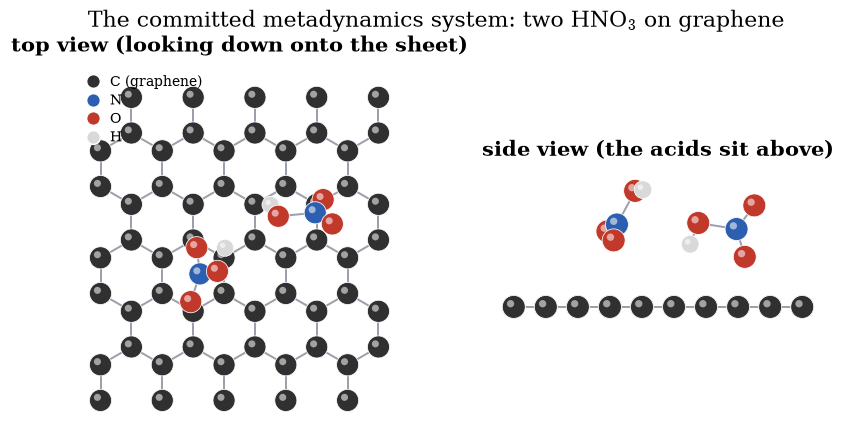

composition: 60×C, 2×H, 2×N, 6×O


In [4]:
# (solution hidden on the public site)


### Validation 1 — graphene plus two nitric-acid molecules

The system must be a carbon sheet (many C) with exactly the atoms of two HNO₃: two N,
six O, two H.

In [5]:
validate.check(
    counts.get("C", 0) >= 50
    and counts.get("N") == 2
    and counts.get("O") == 6
    and counts.get("H") == 2,
    "the system is graphene plus two nitric-acid molecules",
    f"composition {counts}",
)

✓  the system is graphene plus two nitric-acid molecules   [composition {'C': 60, 'H': 2, 'N': 2, 'O': 6}]


True

## Exercise 2 — The collective variables over time

The `COLVAR` log records the three collective variables at every step. Plotting them
against time (Assignment 3) is the first look at what the run actually did, and the
question worth asking of the plot is not whether the variables move — they always do,
thermally — but whether the region they move *in* is still growing. Metadynamics that
is working pushes the system out of what it has already visited, so the explored range
keeps widening. Metadynamics that has stalled fluctuates about a fixed point, and the
range stops growing. The two look similar at a glance and are told apart by measuring.

```{note}
The first few logged samples are a startup transient, recorded before the first hill
was deposited at $t = 100\ \mathrm{fs}$, and they reach further in the C–O coordinate
than the biased run ever does afterwards. Any statement about what the *bias*
accomplished has to be made on $t \ge 100\ \mathrm{fs}$; including the transient
flatters the run with ground it covered before metadynamics had done anything.
```

**Part a)** Load `COLVAR` and plot the three CVs against time.

**Part b)** Decide whether the exploration is still expanding. Restricting to the
biased part of the run, compare the range explored up to the end against the range
already explored in the first quarter, and compare the drift of the quarter-by-quarter
means against the size of the fluctuations about them.

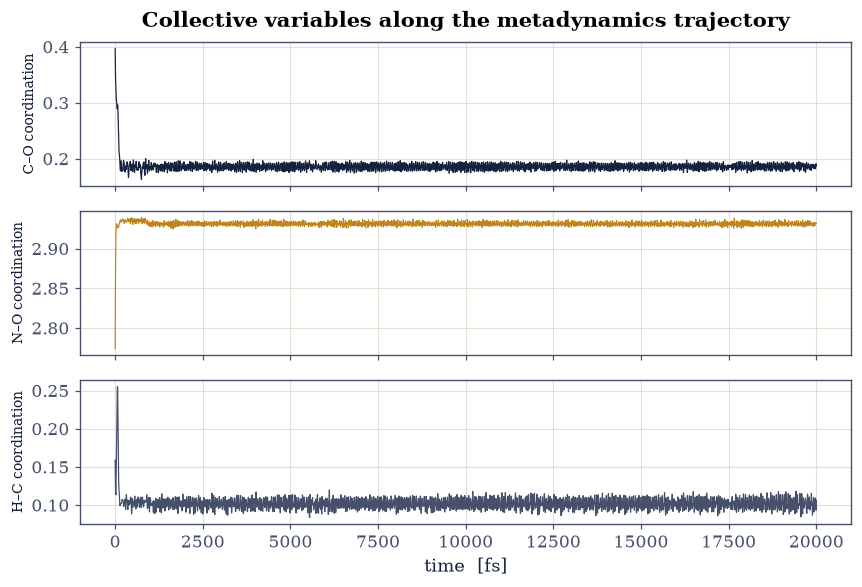

CV explored ranges: {'C–O coordination': np.float64(0.234), 'N–O coordination': np.float64(0.165), 'H–C coordination': np.float64(0.171)}
range growth (end / first quarter): {'C–O coordination': np.float64(1.0), 'N–O coordination': np.float64(1.0), 'H–C coordination': np.float64(1.06)}
quarter-mean drift / fluctuation:   {'C–O coordination': np.float64(0.02), 'N–O coordination': np.float64(0.27), 'H–C coordination': np.float64(0.03)}


In [6]:
# (solution hidden on the public site)


### Validation 2 — the exploration has stalled

The natural check here is the tempting one to get wrong. Asking merely that each
collective variable cover a finite range passes on this data — but only on the
strength of the pre-bias startup transient, so it would certify "the bias drove
exploration" from samples recorded before a single hill existed. Measured on the
biased run alone, the two statements below say the opposite and say it deterministically:
the range explored by the end is the range that was already explored in the first
quarter, and the mean of each variable drifts by a small fraction of its own
fluctuation width. This is a stalled search, and recognising one is the skill.

In [7]:
validate.check(
    bool(np.all(range_growth < 1.15)),
    "the biased run explores no more ground by the end than it had already covered in "
    "its first quarter: the search stopped expanding almost as soon as it started",
    f"range growth {range_growth.round(2)} (end / first quarter)",
)
validate.check(
    bool(np.all(mean_drift < 0.5)),
    "and each collective variable fluctuates about a fixed mean rather than migrating, "
    "the quarter-to-quarter drift being a fraction of the fluctuation it sits in",
    f"drift / fluctuation {mean_drift.round(2)}",
)

✓  the biased run explores no more ground by the end than it had already covered in its first quarter: the search stopped expanding almost as soon as it started   [range growth [1.   1.   1.06] (end / first quarter)]
✓  and each collective variable fluctuates about a fixed mean rather than migrating, the quarter-to-quarter drift being a fraction of the fluctuation it sits in   [drift / fluctuation [0.02 0.27 0.03]]


True

## Exercise 3 — Reconstructing the free-energy surface

The `HILLS` log lists every deposited Gaussian: its centre in CV space, its widths,
and its height. Summing them and flipping the sign reconstructs the free-energy surface
{eq}`eq-metad` (Assignment 4). We project onto two of the variables, the C–O and H–C
coordinations that describe the acid approaching and bonding to the sheet, and contour
the result. The minimum marks the most-visited configuration; because this is a short
run the surface maps the explored basin rather than a fully converged barrier.

**Part a)** Load `HILLS` and reconstruct the 2-D free-energy surface.

**Part b)**
Confirm its minimum coincides with where the trajectory spent the most time.

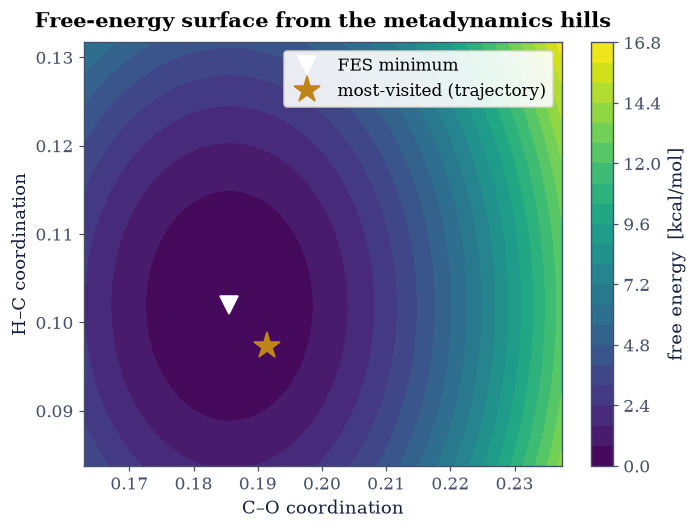

FES minimum at (0.19, 0.10); most-visited at (0.19, 0.10)


In [8]:
# (solution hidden on the public site)


### Validation 3 — the surface is consistent with the trajectory

Metadynamics fills only the basins it visits, so the reconstructed free-energy
minimum must fall where the trajectory spent its time — a self-consistency check
that the `HILLS` reconstruction and the `COLVAR` trajectory tell the same story
(not an independent measurement: the hills are deposited along that trajectory).

In [9]:
span = np.hypot(np.ptp(cv[:, a]), np.ptp(cv[:, b]))
validate.check(
    agreement < 0.25 * span,
    "the reconstructed FES minimum sits where the trajectory spent the most time",
    f"FES min ↔ most-visited distance = {agreement:.3f} ({100*agreement/span:.0f}% of the explored span)",
)

✓  the reconstructed FES minimum sits where the trajectory spent the most time   [FES min ↔ most-visited distance = 0.008 (3% of the explored span)]


True

## Exercise 4 — Watching the hills fill, and asking whether they filled enough

Exercise 3 summed all two hundred hills at once and read a free-energy surface off
the total. That is the right final step, and it hides the two questions a
metadynamics run has to answer before anyone may trust it: *is the bias finished*,
and *what flavour of metadynamics was this anyway*.

Both are answerable from the committed `HILLS` file, and the first is easier to see
than to argue about — so accumulate the bias hill by hill and watch it. Each hill
is a Gaussian dropped at the system's current position in collective-variable space,
so the bias grows fastest exactly where the system has spent the most time, which is
the bottom of a well. As a basin fills, the system stops returning to it and the
hills go elsewhere.

The diagnosis then follows from the shape of that growth. In **standard**
metadynamics every hill has the same height, so the bias in a well-explored region
keeps rising *linearly* for as long as the run continues — it never settles, and one
has to stop and hope. **Well-tempered** metadynamics {cite}`barducci2008` fixes this
by shrinking each hill according to the bias already deposited where it lands,

```{math}
:label: eq-well-tempered
h_i = h_0\,\exp\!\left[-\frac{V(\mathbf s_i, t_i)}{k_B\,\Delta T}\right],
```

so deposition slows as a region fills and the bias converges to a definite limit
rather than growing without bound. The bias-growth curve tells the two apart at a
glance: straight means standard and unconverged; bending over means well-tempered
and settling.

**Part a)** Implement `accumulate_bias(centres, widths, heights, GA, GB)`, returning
the bias on the grid after each hill — a running sum of Gaussians, one frame per
deposition. Project onto the same two collective variables Exercise 3 used, C–O and
H–C.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Animate it, and diagnose the run. Check the recorded hill heights: are
they constant? Then track the maximum bias against the number of hills deposited and
compare its value after 20 hills with its value after 200. If the run were
converging, the later hills would be adding less than the earlier ones.

Two further numbers in the same file are worth extracting, because together they say
what the growth curve alone cannot. Compare the span of the hill *centres* in each
collective variable against the hill *width* recorded beside them, and ask what a
Gaussian several times wider than the whole explored region can possibly resolve.
Then ask how much of the trajectory after the first hill lies inside the box the hill
centres occupy. A run that is exploring should be leaving that box. Finally, measure
how much the accumulated bias actually *varies* across that region, as a fraction of
its own size — remembering that what pushes the system is the gradient of the bias and
not its value, so a bias that rises uniformly is a bias that pushes on nothing.

**Part c)** Apply {eq}`eq-well-tempered` to the *same* hill positions, with
$k_B\Delta T = 0.10$ in the units of the committed file, and re-accumulate. Compare
the two growth curves and the height of the last hill against the first. This is the
same trajectory rebiased under a different rule, so the difference is the rule and
nothing else.

In [10]:
# (solution hidden on the public site)


hill heights: constant to within 0.00e+00 -> standard metadynamics
standard      bias max: 0.0598 (20 hills) -> 0.5993 (200 hills), ratio 10.02
well-tempered bias max: 0.0474 (20 hills) -> 0.1950 (200 hills), ratio 4.12
well-tempered last hill is 14.3 % of the first
hill width / explored span: 3.2x (C–O coordination), 4.5x (H–C coordination) -- the hills are wider than the search
97.9 % of the biased trajectory stays inside the box its own hills occupy
across that box the accumulated bias varies by only 4.4 % of its own height: an offset, not a gradient


### Validation 4 — a straight line is a warning, not a result

Seven checks, all on the committed data and therefore deterministic. The recorded
hill heights must be exactly constant, which identifies the run as standard rather
than well-tempered. The bias must then grow linearly with hill count — tenfold more
hills giving tenfold more bias — which is the quantitative statement that the run has
not converged and that its free-energy surface is a lower bound on the exploration
still to come. Applying the well-tempered rule to the same hills must bend that
growth over, and its hill heights must decay. Two further checks pin the geometry of
the search: the hills must be wider than the region their own centres cover, and the
biased trajectory must still be sitting inside that region at the end, and the bias it
accumulated must be nearly flat across it. Nothing here
says the committed run is wrong; it says the run is short and its hills are coarse,
both of which its own data is able to tell us.

In [11]:
validate.close(
    heights_constant,
    0.0,
    "every recorded hill has the same height, so this is standard metadynamics "
    "and not the well-tempered variant of eq-well-tempered",
    atol=1e-12,
)
validate.close(
    growth_ratio_std,
    10.0,
    "and the bias grows LINEARLY with the number of hills: ten times the hills, "
    "ten times the bias, which is what a fixed-height rule must do in a region "
    "the trajectory keeps revisiting",
    rtol=0.05,
)
validate.check(
    growth_ratio_wt < 0.7 * growth_ratio_std,
    "the well-tempered rule applied to the same hill positions bends that growth "
    "over: deposition slows as the basin fills, which is what makes the bias "
    "converge to a limit instead of rising without bound",
    f"growth ratio {growth_ratio_wt:.2f} (well-tempered) vs "
    f"{growth_ratio_std:.2f} (as run)",
)
validate.check(
    heights_wt[-1] < 0.3 * heights_wt[0] and np.all(np.diff(peak_wt) > 0.0),
    "and its hills shrink as they land in ground the bias already covers, while "
    "the total bias still rises monotonically",
    f"last well-tempered hill = {100*heights_wt[-1]/heights_wt[0]:.1f} % of the first",
)
validate.check(
    bool(np.all(width_to_span > 1.5)),
    "the recorded hill width exceeds the span its own centres cover in BOTH "
    "collective variables, so no feature narrower than the whole explored region "
    "could have been resolved however long the run continued",
    f"width/span = {width_to_span[0]:.1f} ({CV_NAMES[0]}), "
    f"{width_to_span[1]:.1f} ({CV_NAMES[2]})",
)
validate.check(
    frac_confined > 0.9,
    "and the biased trajectory never escapes the box its own hills occupy: this run "
    "filled one basin without crossing out of it, which is the geometric statement "
    "of what the straight growth curve says arithmetically",
    f"{100*frac_confined:.1f} % of the biased trajectory inside the hill box",
)
validate.check(
    bias_flatness < 0.10,
    "and across that region the bias is nearly flat, varying by under a tenth of its "
    "own height: since the dynamics feels the GRADIENT of the bias, these hills raised "
    "the whole neighbourhood without pushing the system out of any part of it, which "
    "is the mechanism behind the two findings above",
    f"bias varies by {100*bias_flatness:.1f} % of its height across the explored region",
)

✓  every recorded hill has the same height, so this is standard metadynamics and not the well-tempered variant of eq-well-tempered   [got 0 vs expected 0 (rtol=1e-06, atol=1e-12)]
✓  and the bias grows LINEARLY with the number of hills: ten times the hills, ten times the bias, which is what a fixed-height rule must do in a region the trajectory keeps revisiting   [got 10.0164 vs expected 10 (rtol=0.05, atol=1e-09)]
✓  the well-tempered rule applied to the same hill positions bends that growth over: deposition slows as the basin fills, which is what makes the bias converge to a limit instead of rising without bound   [growth ratio 4.12 (well-tempered) vs 10.02 (as run)]
✓  and its hills shrink as they land in ground the bias already covers, while the total bias still rises monotonically   [last well-tempered hill = 14.3 % of the first]
✓  the recorded hill width exceeds the span its own centres cover in BOTH collective variables, so no feature narrower than the whole explored region cou

True

## Notebook summary

We followed a metadynamics run of nitric acid over graphene, computed with
density-functional tight binding. The three coordination-number collective variables
settle after a brief startup transient and then fluctuate about fixed values: measured
on the biased part of the run alone, the ground explored by the end is the ground
already explored in the first quarter. Summing the deposited Gaussian hills
reconstructed the free-energy surface of the basin the system stayed in, and its
minimum coincided with the trajectory's most-visited configuration — a consistency
check between the HILLS reconstruction and the independent COLVAR record, since the
two come from different files.

Reading the HILLS file as a record of how the bias was *built* rather than only of
what it summed to, we found the run diagnosing itself: constant hill heights identify
it as standard rather than well-tempered metadynamics, the maximum bias grows
strictly linearly with hill count, the trajectory never leaves the box its own hills
occupy, and the hills are wider than that box in both collective variables — so wide
that the accumulated bias varies by only a few percent across the region it covers.
That last number is the mechanism behind the others: what drives the dynamics is the
gradient of the bias, and hills too broad to build one raise the neighbourhood without
pushing the system anywhere in it.
Re-accumulating the same hill positions under the well-tempered rule bends the growth
over and shrinks the last hill to a fraction of the first. None of that makes the
committed calculation wrong — it makes it short, and short in ways its own output
states plainly once the growth curve is plotted.

## Outlook

- **Convergence.** A converged free-energy surface needs the bias to grow flat; the
  short run here does not reach that. **Well-tempered** metadynamics shrinks the hills
  over time and converges cleanly.
- **Choosing CVs.** The result is only as good as the collective variables: a CV that
  misses the true slow mode leaves a hidden barrier. The exercise's four candidate CVs
  (coordination numbers and a point-to-plane distance) are a study in that choice.
- **The dissociation.** With a longer run the H–O bond of nitric acid breaks and the
  proton transfers, the dissociation the exercise is named for, appearing as a second
  basin across a barrier in the H–C coordination.
- **Reweighting.** The deposited bias can be used to reweight the trajectory back to
  unbiased ensemble averages of other observables.

### References

```{bibliography}
:filter: docname in docnames
```

In [12]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>